# Computational time versus cell number for all cases

Extracting timing data for Unweighted Periodic...
Extracting timing data for Weighted Periodic...
Extracting timing data for Unweighted Finite...
Extracting timing data for Weighted Finite...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Grid plot successfully generated and saved!


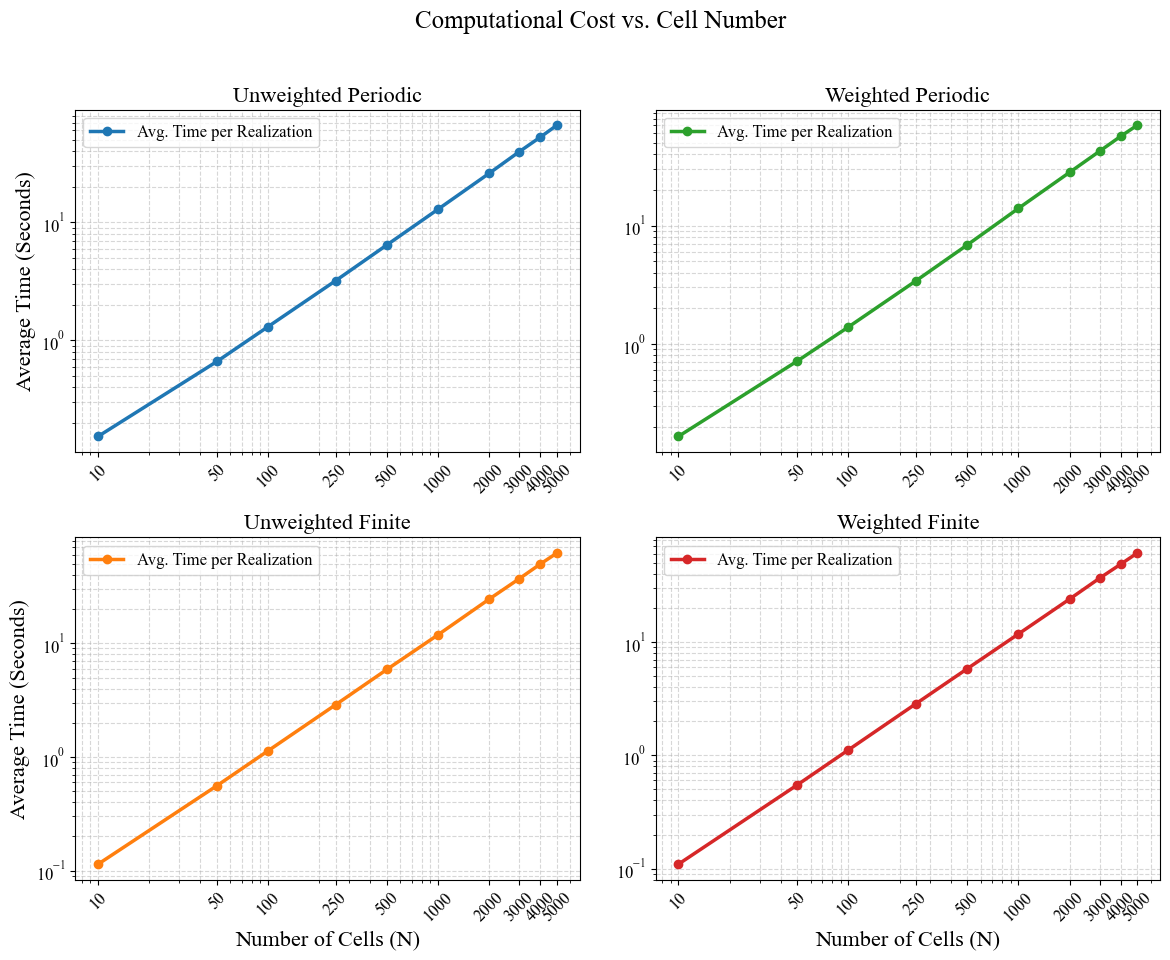

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==========================================
# 1) Setup & Publication styling
# ==========================================
# Match academic journal font settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})

N_values = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

# Map the 4 folders to their grid positions: (row, col)
# Rows: 0=Periodic, 1=Finite
# Cols: 0=Unweighted, 1=Weighted
configs = [
    {
        "folder": "a_unweighted_periodic", 
        "title": "Unweighted Periodic", 
        "pos": (0, 0), 
        "color": "tab:blue"
    },
    {
        "folder": "c_weighted_periodic", 
        "title": "Weighted Periodic", 
        "pos": (0, 1), 
        "color": "tab:green"
    },
    {
        "folder": "b_unweighted_finite", 
        "title": "Unweighted Finite", 
        "pos": (1, 0), 
        "color": "tab:orange"
    },
    {
        "folder": "d_weighted_finite", 
        "title": "Weighted Finite", 
        "pos": (1, 1), 
        "color": "tab:red"
    }
]

# ==========================================
# 2) Figure Setup
# ==========================================
fig, axes = plt.subplots(
    nrows=2, 
    ncols=2, 
    figsize=(14, 10), 
    gridspec_kw={'wspace': 0.15, 'hspace': 0.25}
)

# ==========================================
# 3) Data Extraction & Plotting Loop
# ==========================================
for config in configs:
    row_idx, col_idx = config["pos"]
    ax = axes[row_idx, col_idx]
    
    folder = config["folder"]
    color = config["color"]
    title = config["title"]
    
    times = []
    valid_N = []
    
    print(f"Extracting timing data for {title}...")
    
    for N in N_values:
        path_primary = os.path.join(folder, f"cell_data_{N}", 'average_time.npy')
        path_fallback = os.path.join(folder, str(N), 'average_time.npy')
        
        file_path = None
        if os.path.exists(path_primary):
            file_path = path_primary
        elif os.path.exists(path_fallback):
            file_path = path_fallback
            
        if file_path:
            # Load the 1D array and extract the single float value
            avg_time = np.load(file_path)[0]
            times.append(avg_time)
            valid_N.append(N)
        else:
            pass # Silent skip if N folder isn't found
            
    # Plot if data exists
    if valid_N:
        times = np.array(times)

        # Plot log-log trend line
        ax.plot(valid_N, times, '-o', color=color, markersize=6,
                linewidth=2.5, label='Avg. Time per Realization')

    # Formatting for this specific subplot
    ax.set_title(title)
    
    # Set BOTH axes to log scale for time complexity
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Prevent scientific notation on X axis (so it shows 1000 instead of 10^3)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks(N_values)
    ax.set_xticklabels([str(n) for n in N_values], rotation=45)
    
    # Only show Y-label on the left column to keep it clean
    if col_idx == 0:
        ax.set_ylabel(r"Average Time (Seconds)")
        
    # Only show X-label on the bottom row
    if row_idx == 1:
        ax.set_xlabel("Number of Cells (N)")
        
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(loc='upper left')

# ==========================================
# 4) Export and Show
# ==========================================
fig.suptitle("Computational Cost vs. Cell Number", y=0.98)

plt.savefig('All_Algorithms_Time_Scaling_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('All_Algorithms_Time_Scaling_2x2.eps', format='eps', bbox_inches='tight')

print("\nGrid plot successfully generated and saved!")
plt.show()

# Computation time versus cell number for unweighted periodic only

Extracting timing data for Unweighted Periodic...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as 'a_unweighted_periodic_Time_Scaling_Fit.png'


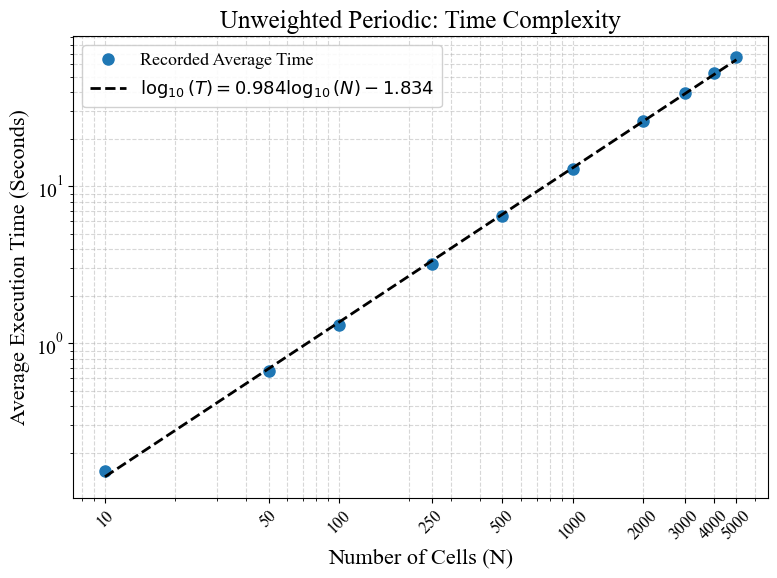

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==========================================
# 1) Setup & Publication styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

folder = "a_unweighted_periodic"
N_values = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

times = []
valid_N = []

# ==========================================
# 2) Data Extraction
# ==========================================
print(f"Extracting timing data for Unweighted Periodic...")

for N in N_values:
    path_primary = os.path.join(folder, f"cell_data_{N}", 'average_time.npy')
    path_fallback = os.path.join(folder, str(N), 'average_time.npy')
    
    file_path = None
    if os.path.exists(path_primary):
        file_path = path_primary
    elif os.path.exists(path_fallback):
        file_path = path_fallback
        
    if file_path:
        avg_time = np.load(file_path)[0]
        times.append(avg_time)
        valid_N.append(N)
    else:
        print(f"  -> Warning: Data not found for N={N}")

# ==========================================
# 3) Mathematical Fit & Plotting
# ==========================================
if valid_N:
    valid_N = np.array(valid_N)
    times = np.array(times)

    # Perform a linear fit in log-log space: log10(T) = k * log10(N) + b
    log_N = np.log10(valid_N)
    log_T = np.log10(times)
    k, b = np.polyfit(log_N, log_T, 1)
    
    # Generate the fitted Y values
    fit_times = 10**(k * log_N + b)
    
    # Format the equation for the legend (clean math only)
    fit_eq = f"$\\log_{{10}}(T) = {k:.3f} \\log_{{10}}(N) {b:+.3f}$"

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot actual data points
    ax.plot(valid_N, times, 'o', color='tab:blue', markersize=8, label="Recorded Average Time")
    
    # Plot the fit line with just the equation
    ax.plot(valid_N, fit_times, '--', color='black', linewidth=2, label=fit_eq)

    # Formatting
    ax.set_title("Unweighted Periodic: Time Complexity")
    ax.set_xlabel("Number of Cells (N)")
    ax.set_ylabel("Average Execution Time (Seconds)")
    
    # Log-Log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Format X-axis to show regular numbers
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks(N_values)
    ax.set_xticklabels([str(n) for n in N_values], rotation=45)
    
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(loc='upper left', framealpha=0.9)

    plt.tight_layout()

    # Export
    out_png = f'{folder}_Time_Scaling_Fit.png'
    out_eps = f'{folder}_Time_Scaling_Fit.eps'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.savefig(out_eps, format='eps', bbox_inches='tight')

    print(f"\nPlot saved successfully as '{out_png}'")
    plt.show()

else:
    print("\nNo data found to plot. Please check your directory structure.")

# Full figure

Extracting data from 'a_unweighted_periodic' at step 80...


/var/folders/r6/5h5k9z756f50_klfmvf_7cp40000gn/T/ipykernel_21568/1962055787.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as 'a_unweighted_periodic_table_and_plot.png'


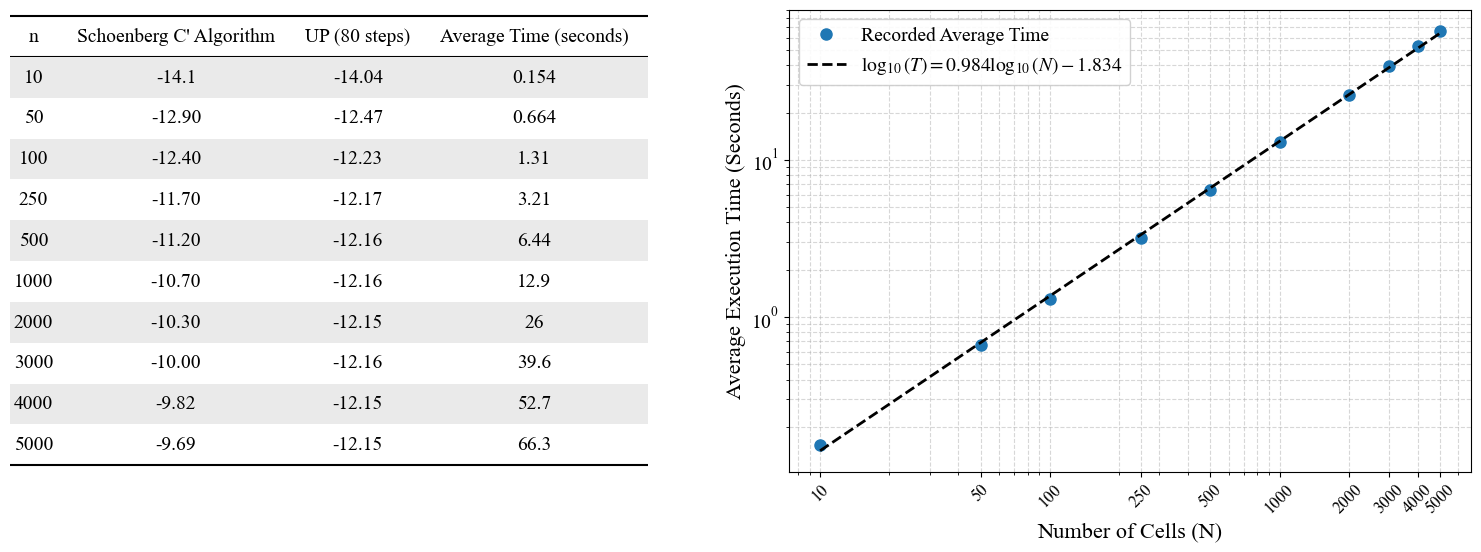

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==========================================
# 1) Setup & Publication styling
# ==========================================
# Added 'stix' mathtext fontset to ensure math formulas match Times New Roman
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

folder = "a_unweighted_periodic"
step_idx = 79  # Index 79 corresponds to Step 80
N_values = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

# Fixed data from the image for the Schoenberg C' Algorithm column
schoenberg = [-14.1, -12.9, -12.4, -11.7, -11.2, -10.7, -10.3, -10.0, -9.82, -9.69]

proposed_rms = []
avg_times = []
valid_N = []
valid_schoenberg = []

# ==========================================
# 2) Data Extraction
# ==========================================
print(f"Extracting data from '{folder}' at step {step_idx + 1}...")

for i, N in enumerate(N_values):
    path_primary = os.path.join(folder, f"cell_data_{N}")
    path_fallback = os.path.join(folder, str(N))
    
    base_path = path_primary if os.path.exists(path_primary) else path_fallback
    
    rms_file = os.path.join(base_path, 'log_rms_vs_steps.npy')
    time_file = os.path.join(base_path, 'average_time.npy')
    
    if os.path.exists(rms_file) and os.path.exists(time_file):
        rms_data = np.load(rms_file)
        time_data = np.load(time_file)
        
        # Safely get the target step
        idx = step_idx if rms_data.shape[1] > step_idx else -1
        
        proposed_rms.append(rms_data[0, idx])
        avg_times.append(time_data[0])
        valid_N.append(N)
        valid_schoenberg.append(schoenberg[i])

if not valid_N:
    print("No data found. Please check your directory structure.")
    exit()

# ==========================================
# 3) Figure Setup (1x2 Grid)
# ==========================================
# Increased wspace to 0.25 to shift the plot right and prevent overlap
# Increased right width_ratio to elongate the plot further
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.35)

# ------------------------------------------
# LEFT: TABLE
# ------------------------------------------
ax_tab = fig.add_subplot(gs[0])
ax_tab.axis('off')

# Prepare table data
col_labels = ['n', "Schoenberg C' Algorithm", 'UP (80 steps)', 'Average Time (seconds)']
table_data = []
for n, sch, prop, t in zip(valid_N, valid_schoenberg, proposed_rms, avg_times):
    sch_str = f"{sch:.2f}" if sch != -14.1 else "-14.1"
    table_data.append([str(n), sch_str, f"{prop:.2f}", f"{t:.3g}"])

# Create Table
table = ax_tab.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')

# Auto-adjust column widths
table.auto_set_column_width(col=list(range(len(col_labels))))

# Scaled the table vertically to match plot height, kept width scale standard
table.scale(1.55, 2.45) 
table.auto_set_font_size(False)
table.set_fontsize(14)

# Format Borders and Colors (Isolated logic to ensure 5000 is shaded)
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0)
    
    # Border Logic
    if row == 0:
        cell.set_text_props(weight='normal')
        cell.visible_edges = 'BT'  
        cell.set_linewidth(1.5)
    elif row == len(table_data):
        cell.visible_edges = 'B'   
        cell.set_linewidth(1.5)
        
    # Shading Logic (Strictly applies to all even data rows, including row 10 / N=5000)
    if row in [1, 3, 5, 7, 9]:
        cell.set_facecolor('#eaeaea')

# ------------------------------------------
# RIGHT: PLOT
# ------------------------------------------
ax_plot = fig.add_subplot(gs[1])

valid_N_arr = np.array(valid_N)
times_arr = np.array(avg_times)

# Perform a linear fit in log-log space
log_N = np.log10(valid_N_arr)
log_T = np.log10(times_arr)
k, b = np.polyfit(log_N, log_T, 1)

# Generate the fitted Y values
fit_times = 10**(k * log_N + b)

# Format the equation for the legend 
fit_eq = f"$\\log_{{10}}(T) = {k:.3f} \\log_{{10}}(N) {b:+.3f}$"

# Plot actual data points
ax_plot.plot(valid_N_arr, times_arr, 'o', color='tab:blue', markersize=8, label="Recorded Average Time")

# Plot the fit line
ax_plot.plot(valid_N_arr, fit_times, '--', color='black', linewidth=2, label=fit_eq)

# Formatting
ax_plot.set_xlabel("Number of Cells (N)")
ax_plot.set_ylabel("Average Execution Time (Seconds)")

# Log-Log scale
ax_plot.set_xscale('log')
ax_plot.set_yscale('log')

# Format X-axis to show regular numbers
ax_plot.xaxis.set_major_formatter(ScalarFormatter())
ax_plot.set_xticks(N_values)
ax_plot.set_xticklabels([str(n) for n in N_values], rotation=45)

ax_plot.grid(True, which="both", ls="--", alpha=0.5)
ax_plot.legend(loc='upper left', framealpha=0.9)

# ==========================================
# 4) Final Cleanup and Export
# ==========================================
plt.tight_layout()

out_png = f'{folder}_table_and_plot.png'
out_eps = f'{folder}_table_and_plot.eps'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.savefig(out_eps, format='eps', bbox_inches='tight')

print(f"\nPlot saved successfully as '{out_png}'")
plt.show()

Extracting data from 'a_unweighted_periodic' at step 80...


/var/folders/r6/5h5k9z756f50_klfmvf_7cp40000gn/T/ipykernel_21568/1032596612.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as 'a_unweighted_periodic_table_and_plot.png'


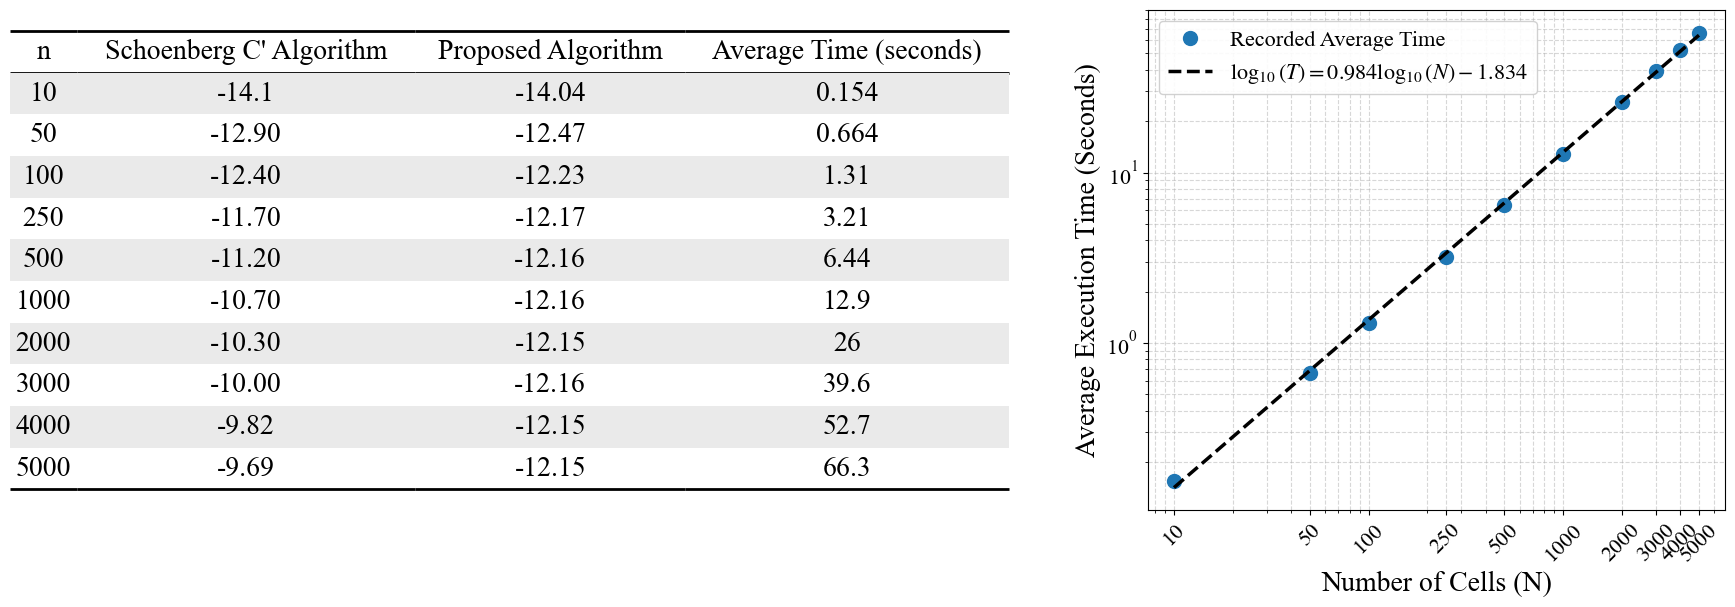

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==========================================
# 1) Setup & Publication styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 18,          # Large base font
    'axes.labelsize': 20,     # Large axis labels
    'axes.titlesize': 22,     # Large titles
    'xtick.labelsize': 16,    # Large ticks
    'ytick.labelsize': 16,    
    'legend.fontsize': 16     # Large legend
})

folder = "a_unweighted_periodic"
step_idx = 79  # Index 79 corresponds to Step 80
N_values = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

# Fixed data from the image for the Schoenberg C' Algorithm column
schoenberg = [-14.1, -12.9, -12.4, -11.7, -11.2, -10.7, -10.3, -10.0, -9.82, -9.69]

proposed_rms = []
avg_times = []
valid_N = []
valid_schoenberg = []

# ==========================================
# 2) Data Extraction
# ==========================================
print(f"Extracting data from '{folder}' at step {step_idx + 1}...")

for i, N in enumerate(N_values):
    path_primary = os.path.join(folder, f"cell_data_{N}")
    path_fallback = os.path.join(folder, str(N))
    
    base_path = path_primary if os.path.exists(path_primary) else path_fallback
    
    rms_file = os.path.join(base_path, 'log_rms_vs_steps.npy')
    time_file = os.path.join(base_path, 'average_time.npy')
    
    if os.path.exists(rms_file) and os.path.exists(time_file):
        rms_data = np.load(rms_file)
        time_data = np.load(time_file)
        
        # Safely get the target step
        idx = step_idx if rms_data.shape[1] > step_idx else -1
        
        proposed_rms.append(rms_data[0, idx])
        avg_times.append(time_data[0])
        valid_N.append(N)
        valid_schoenberg.append(schoenberg[i])

if not valid_N:
    print("No data found. Please check your directory structure.")
    exit()

# ==========================================
# 3) Figure Setup (1x2 Grid)
# ==========================================
# Canvas size kept smaller so the fonts actually look huge
fig = plt.figure(figsize=(19, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1.35], wspace=0.70)

# ------------------------------------------
# LEFT: TABLE
# ------------------------------------------
ax_tab = fig.add_subplot(gs[0])
ax_tab.axis('off')

# Prepare table data
col_labels = ['n', "Schoenberg C' Algorithm", 'Proposed Algorithm', 'Average Time (seconds)']
table_data = []
for n, sch, prop, t in zip(valid_N, valid_schoenberg, proposed_rms, avg_times):
    sch_str = f"{sch:.2f}" if sch != -14.1 else "-14.1"
    table_data.append([str(n), sch_str, f"{prop:.2f}", f"{t:.3g}"])

# Create Table
table = ax_tab.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')

# Auto-adjust column widths
table.auto_set_column_width(col=list(range(len(col_labels))))

# Scale to fit the new font size
table.scale(1.05, 2.5) 
table.auto_set_font_size(False)
table.set_fontsize(20)  # Forced large font size on smaller canvas

# Format Borders and Colors
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0)
    
    if row == 0:
        cell.set_text_props(weight='normal')
        cell.visible_edges = 'BT'  
        cell.set_linewidth(2.0)
    elif row == len(table_data):
        cell.visible_edges = 'B'   
        cell.set_linewidth(2.0)
        
    if row in [1, 3, 5, 7, 9]:
        cell.set_facecolor('#eaeaea')

# Table Footer Note
# ax_tab.text(0.5, 0.0, "Log (base 10) of RMS errors of spot location estimates", 
#             ha='center', va='center', fontsize=18, transform=ax_tab.transAxes)

# ------------------------------------------
# RIGHT: PLOT
# ------------------------------------------
ax_plot = fig.add_subplot(gs[1])

valid_N_arr = np.array(valid_N)
times_arr = np.array(avg_times)

# Perform a linear fit in log-log space
log_N = np.log10(valid_N_arr)
log_T = np.log10(times_arr)
k, b = np.polyfit(log_N, log_T, 1)

# Generate the fitted Y values
fit_times = 10**(k * log_N + b)

# Format the equation for the legend 
fit_eq = f"$\\log_{{10}}(T) = {k:.3f} \\log_{{10}}(N) {b:+.3f}$"

# Plot actual data points
ax_plot.plot(valid_N_arr, times_arr, 'o', color='tab:blue', markersize=10, label="Recorded Average Time")

# Plot the fit line
ax_plot.plot(valid_N_arr, fit_times, '--', color='black', linewidth=2.5, label=fit_eq)

# Formatting
ax_plot.set_xlabel("Number of Cells (N)")
ax_plot.set_ylabel("Average Execution Time (Seconds)")

# Log-Log scale
ax_plot.set_xscale('log')
ax_plot.set_yscale('log')

# Format X-axis to show regular numbers
ax_plot.xaxis.set_major_formatter(ScalarFormatter())
ax_plot.set_xticks(N_values)
ax_plot.set_xticklabels([str(n) for n in N_values], rotation=45)

ax_plot.grid(True, which="both", ls="--", alpha=0.5)
ax_plot.legend(loc='upper left', framealpha=0.9)

# ==========================================
# 4) Final Cleanup and Export
# ==========================================
plt.tight_layout()

out_png = f'{folder}_table_and_plot.png'
out_eps = f'{folder}_table_and_plot.eps'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.savefig(out_eps, format='eps', bbox_inches='tight')

print(f"\nPlot saved successfully as '{out_png}'")
plt.show()

Extracting data from 'a_unweighted_periodic' at step 80...


/var/folders/r6/5h5k9z756f50_klfmvf_7cp40000gn/T/ipykernel_21568/3889844092.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as 'a_unweighted_periodic_table_and_plot.png'


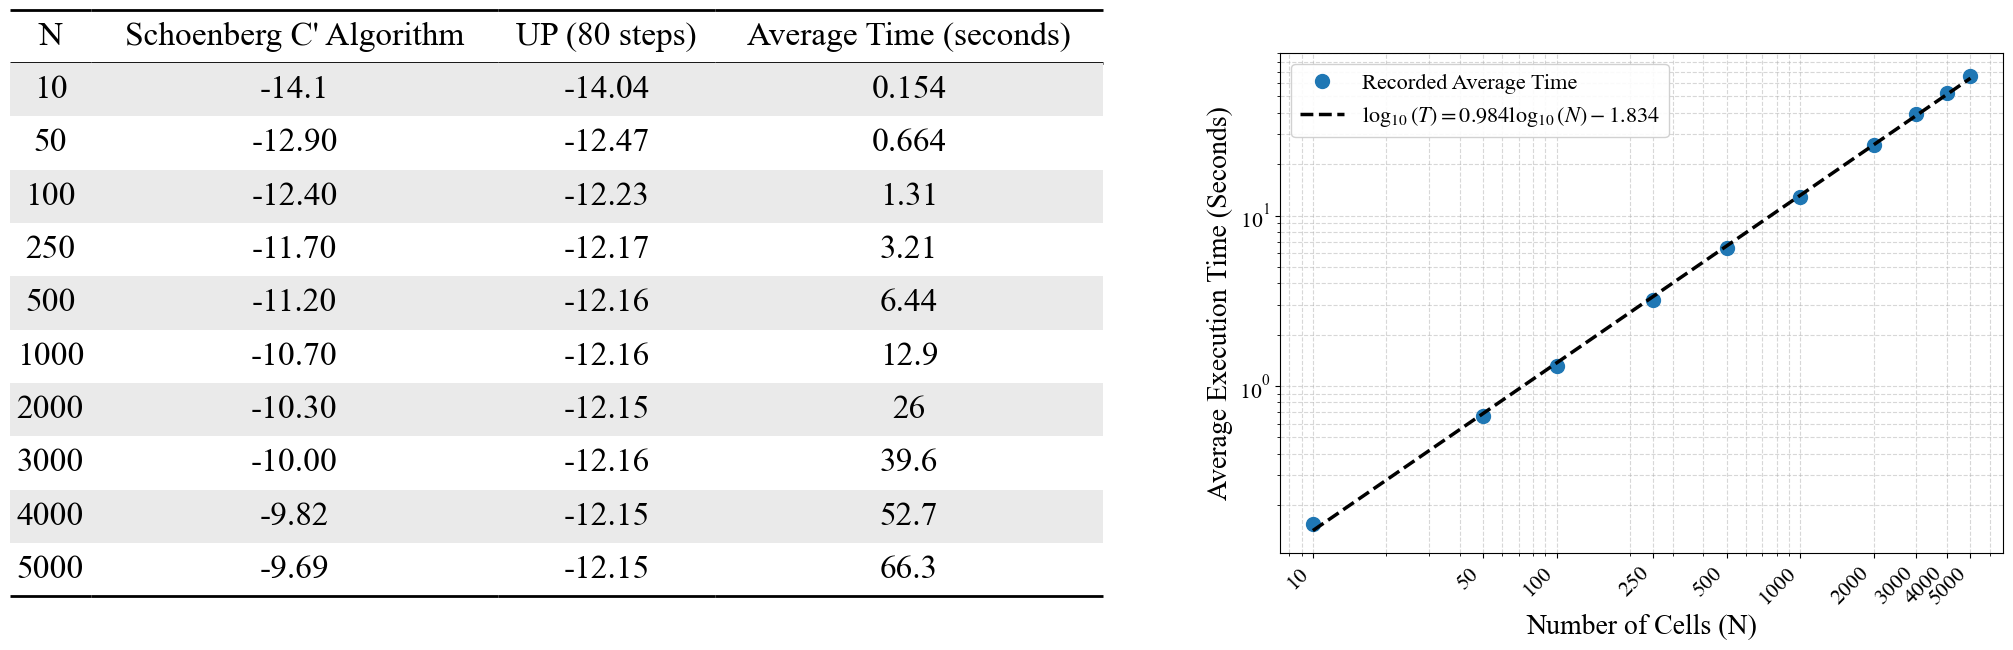

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==========================================
# 1) Setup & Publication styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 18,          
    'axes.labelsize': 20,     
    'axes.titlesize': 22,     
    'xtick.labelsize': 16,    
    'ytick.labelsize': 16,    
    'legend.fontsize': 16     
})

folder = "a_unweighted_periodic"
step_idx = 79  # Index 79 corresponds to Step 80
N_values = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

# Fixed data from the image for the Schoenberg C' Algorithm column
schoenberg = [-14.1, -12.9, -12.4, -11.7, -11.2, -10.7, -10.3, -10.0, -9.82, -9.69]

proposed_rms = []
avg_times = []
valid_N = []
valid_schoenberg = []

# ==========================================
# 2) Data Extraction
# ==========================================
print(f"Extracting data from '{folder}' at step {step_idx + 1}...")

for i, N in enumerate(N_values):
    path_primary = os.path.join(folder, f"cell_data_{N}")
    path_fallback = os.path.join(folder, str(N))
    
    base_path = path_primary if os.path.exists(path_primary) else path_fallback
    
    rms_file = os.path.join(base_path, 'log_rms_vs_steps.npy')
    time_file = os.path.join(base_path, 'average_time.npy')
    
    if os.path.exists(rms_file) and os.path.exists(time_file):
        rms_data = np.load(rms_file)
        time_data = np.load(time_file)
        
        # Safely get the target step
        idx = step_idx if rms_data.shape[1] > step_idx else -1
        
        proposed_rms.append(rms_data[0, idx])
        avg_times.append(time_data[0])
        valid_N.append(N)
        valid_schoenberg.append(schoenberg[i])

if not valid_N:
    print("No data found. Please check your directory structure.")
    exit()

# ==========================================
# 3) Figure Setup (1x2 Grid)
# ==========================================
# Increased figure width to 22 to stretch the x-axis and prevent overlap
fig = plt.figure(figsize=(22, 6.5))
# Adjusted ratios to give the plot significantly more horizontal room
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=0.75)

# ------------------------------------------
# LEFT: TABLE
# ------------------------------------------
ax_tab = fig.add_subplot(gs[0])
ax_tab.axis('off')

# Prepare table data
col_labels = ['N', "Schoenberg C' Algorithm", 'UP (80 steps)', 'Average Time (seconds)']
table_data = []
for n, sch, prop, t in zip(valid_N, valid_schoenberg, proposed_rms, avg_times):
    sch_str = f"{sch:.2f}" if sch != -14.1 else "-14.1"
    table_data.append([str(n), sch_str, f"{prop:.2f}", f"{t:.3g}"])

# Create Table
table = ax_tab.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')

# Auto-adjust column widths
table.auto_set_column_width(col=list(range(len(col_labels))))

# Scaled table height drastically (3.2x) to match the new figure height
table.scale(1.15, 3.2) 
table.auto_set_font_size(False)
table.set_fontsize(24)

# Format Borders and Colors
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0)
    
    if row == 0:
        cell.set_text_props(weight='normal')
        cell.visible_edges = 'BT'  
        cell.set_linewidth(2.0)
    elif row == len(table_data):
        cell.visible_edges = 'B'   
        cell.set_linewidth(2.0)
        
    if row in [1, 3, 5, 7, 9]:
        cell.set_facecolor('#eaeaea')


# ------------------------------------------
# RIGHT: PLOT
# ------------------------------------------
ax_plot = fig.add_subplot(gs[1])

valid_N_arr = np.array(valid_N)
times_arr = np.array(avg_times)

# Perform a linear fit in log-log space
log_N = np.log10(valid_N_arr)
log_T = np.log10(times_arr)
k, b = np.polyfit(log_N, log_T, 1)

# Generate the fitted Y values
fit_times = 10**(k * log_N + b)

# Format the equation for the legend 
fit_eq = f"$\\log_{{10}}(T) = {k:.3f} \\log_{{10}}(N) {b:+.3f}$"

# Plot actual data points
ax_plot.plot(valid_N_arr, times_arr, 'o', color='tab:blue', markersize=10, label="Recorded Average Time")

# Plot the fit line
ax_plot.plot(valid_N_arr, fit_times, '--', color='black', linewidth=2.5, label=fit_eq)

# Formatting
ax_plot.set_xlabel("Number of Cells (N)")
ax_plot.set_ylabel("Average Execution Time (Seconds)")

# Log-Log scale
ax_plot.set_xscale('log')
ax_plot.set_yscale('log')

# Format X-axis to show regular numbers
ax_plot.xaxis.set_major_formatter(ScalarFormatter())
ax_plot.set_xticks(N_values)
# Adding ha='right' anchors the rotated text on the right edge, preventing overlap
ax_plot.set_xticklabels([str(n) for n in N_values], rotation=45, ha='right')

ax_plot.grid(True, which="both", ls="--", alpha=0.5)
ax_plot.legend(loc='upper left', framealpha=0.9)

# ==========================================
# 4) Final Cleanup and Export
# ==========================================
plt.tight_layout()

out_png = f'{folder}_table_and_plot.png'
out_eps = f'{folder}_table_and_plot.eps'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.savefig(out_eps, format='eps', bbox_inches='tight')

print(f"\nPlot saved successfully as '{out_png}'")
plt.show()